In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels flask

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("pakistan_economy.csv")
print(df.head())

   Year  GDP_Billion_USD  Inflation_%  Unemployment_%  Exports_Billion_USD  \
0  1990       274.835708     6.723471        6.971533            27.615149   
1  1990       328.960641     8.534869        5.295788            22.712800   
2  1990       262.098114     3.173440        3.412623            17.188562   
3  1990       204.598796     4.175393        8.198473            18.871119   
4  1990       222.780864     7.221845        4.273510            21.878490   

   Imports_Billion_USD  Population_Million  
0            23.595080          109.765863  
1            22.219494          109.534270  
2            18.923013          110.314247  
3            25.405169          108.575252  
4            21.396168          109.708306  


In [3]:
print(df.describe())

              Year  GDP_Billion_USD  Inflation_%  Unemployment_%  \
count  7000.000000      7000.000000  7000.000000     7000.000000   
mean   2007.000000       283.767722     6.991933        6.006043   
std      10.100226        54.459681     1.977422        1.504481   
min    1990.000000        89.181234     0.127875        0.116400   
25%    1998.000000       246.249064     5.607811        4.997783   
50%    2007.000000       282.662176     6.988126        6.024974   
75%    2016.000000       321.313176     8.356124        7.009516   
max    2024.000000       494.826583    13.857821       11.591750   

       Exports_Billion_USD  Imports_Billion_USD  Population_Million  
count          7000.000000          7000.000000         7000.000000  
mean             28.416231            35.227008          144.012096  
std               7.100241             8.577368           20.230015  
min               4.558174             5.552396          107.151457  
25%              23.421389           

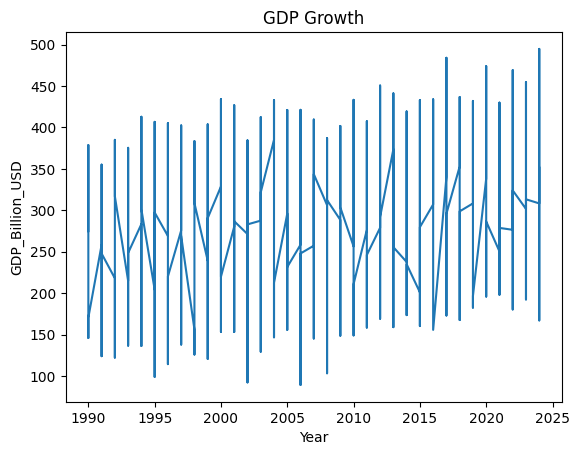

In [4]:
import matplotlib.pyplot as plt

plt.plot(df['Year'], df['GDP_Billion_USD'])
plt.title("GDP Growth")
plt.xlabel("Year")
plt.ylabel("GDP_Billion_USD")
plt.show()

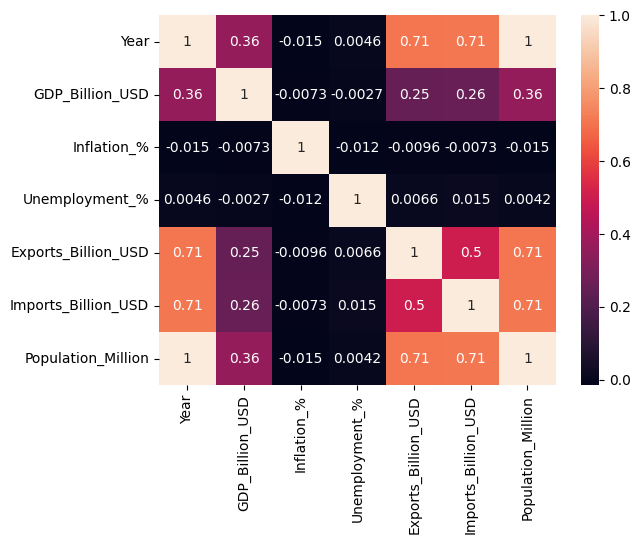

In [5]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

X = df[['Year']]
y = df['GDP_Billion_USD']

model = LinearRegression()
model.fit(X, y)

future_years = [[2025], [2026], [2027]]
predictions = model.predict(future_years)

print(predictions)

[319.04509258 321.00494648 322.96480039]


C:\Users\PCP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['GDP_Billion_USD'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=3)
print(forecast)

7000    321.253038
7001    321.099586
7002    321.098806
Name: predicted_mean, dtype: float64



     PAKISTAN ECONOMIC FORECAST (2025-2027)     
Year       | Inflation %     | Unemployment % 
--------------------------------------------------


C:\Users\SCO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\SCO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


2025       | 6.87            | 6.06           
2026       | 6.86            | 6.06           
2027       | 6.84            | 6.07           


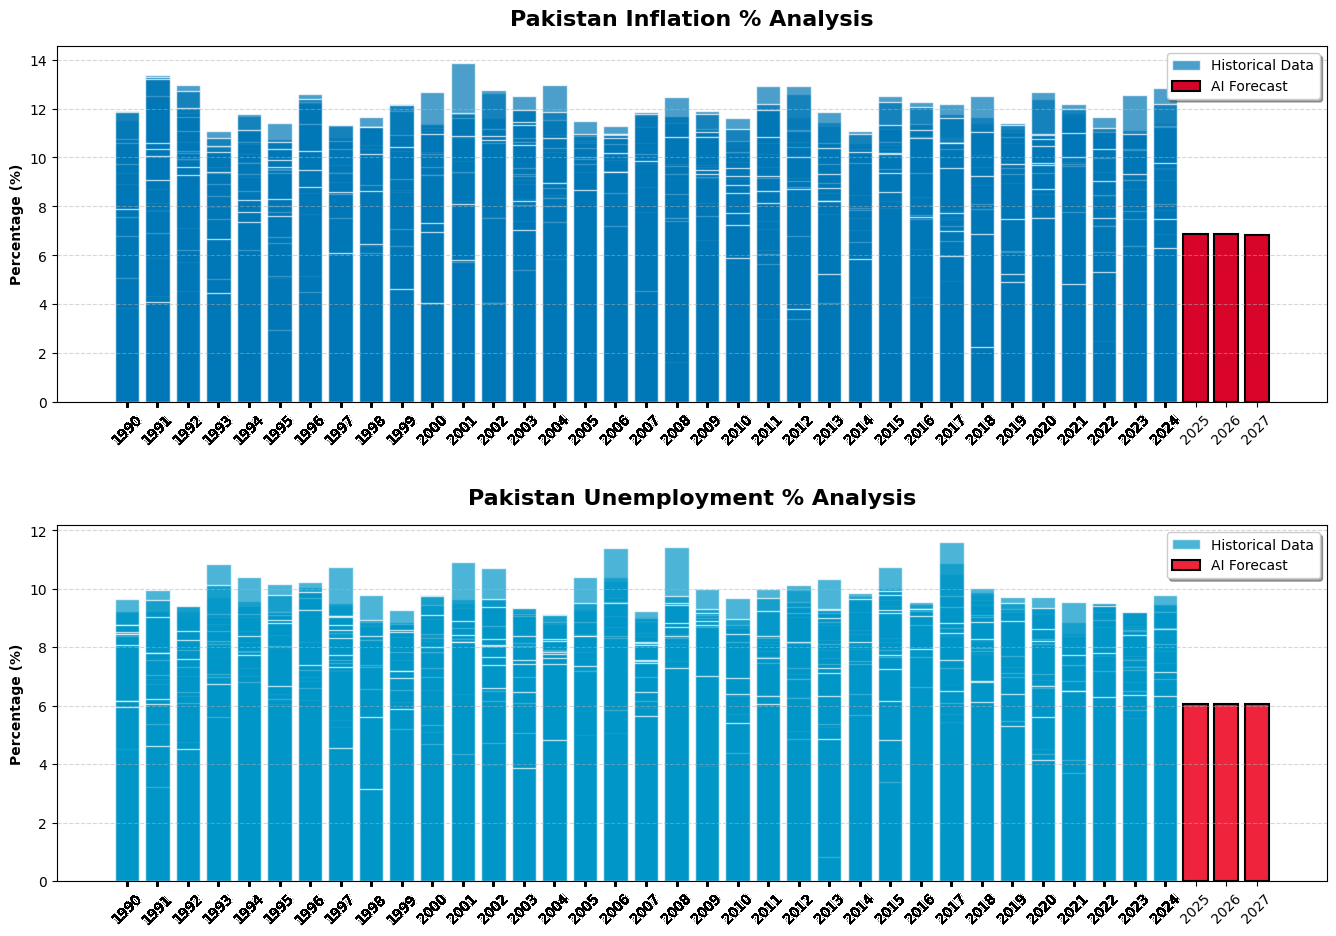

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


df = pd.read_csv('pakistan_economy.csv')


future_years = [2025, 2026, 2027]
future_years_arr = np.array(future_years).reshape(-1, 1)
targets = ['Inflation_%', 'Unemployment_%']


colors_past = ['#0077b6', '#0096c7'] 
colors_pred = ['#d90429', '#ef233c']


print("\n" + "="*50)
print("     PAKISTAN ECONOMIC FORECAST (2025-2027)     ")
print("="*50)
print(f"{'Year':<10} | {'Inflation %':<15} | {'Unemployment %':<15}")
print("-" * 50)


final_preds = {}

plt.figure(figsize=(14, 10))
plt.style.use('seaborn-v0_8-muted') # Modern look

for i, col in enumerate(targets):
   
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(df[['Year']])
    model = LinearRegression()
    model.fit(X_poly, df[col])
    
    
    preds = model.predict(poly.transform(future_years_arr))
    final_preds[col] = preds

    
    plt.subplot(2, 1, i+1)
    
   
    plt.bar(df['Year'], df[col], color=colors_past[i], alpha=0.7, 
            edgecolor='white', label='Historical Data')
    
   
    plt.bar(future_years, preds, color=colors_pred[i], 
            edgecolor='black', linewidth=1.5, label='AI Forecast')
    
   
    plt.title(f'Pakistan {col.replace("_"," ")} Analysis', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Percentage (%)', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(frameon=True, shadow=True)
    plt.xticks(list(df['Year'][::3]) + future_years, rotation=45)

 
for idx, year in enumerate(future_years):
    inf = final_preds['Inflation_%'][idx]
    unemp = final_preds['Unemployment_%'][idx]
    print(f"{year:<10} | {inf:<15.2f} | {unemp:<15.2f}")

print("="*50)
plt.tight_layout(pad=3.0)
plt.savefig("static/inflation_unemployment.png", bbox_inches="tight")
plt.show()

In [3]:
from sklearn.linear_model import LinearRegression


X = df[['Year', 'Exports_Billion_USD']] 
y = df['GDP_Billion_USD']

model_multi = LinearRegression()
model_multi.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [4]:
# 1. Maan lete hain 2027 mein exports wahi hain jo last record mein thay (e.g. 30 Billion)
current_exports = df['Exports_Billion_USD'].iloc[-1] 

# 2. 10% Izafa (Increase)
increased_exports = current_exports * 1.10 

# 3. Dono scenarios ki prediction
pred_normal = model_multi.predict([[2027, current_exports]])
pred_boosted = model_multi.predict([[2027, increased_exports]])

print(f"2027 GDP (Normal Exports): {pred_normal[0]:.2f} Billion USD")
print(f"2027 GDP (10% Export Increase): {pred_boosted[0]:.2f} Billion USD")
print(f"Extra Benefit to Economy: {pred_boosted[0] - pred_normal[0]:.2f} Billion USD")

2027 GDP (Normal Exports): 322.80 Billion USD
2027 GDP (10% Export Increase): 322.44 Billion USD
Extra Benefit to Economy: -0.35 Billion USD


C:\Users\PCP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\PCP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


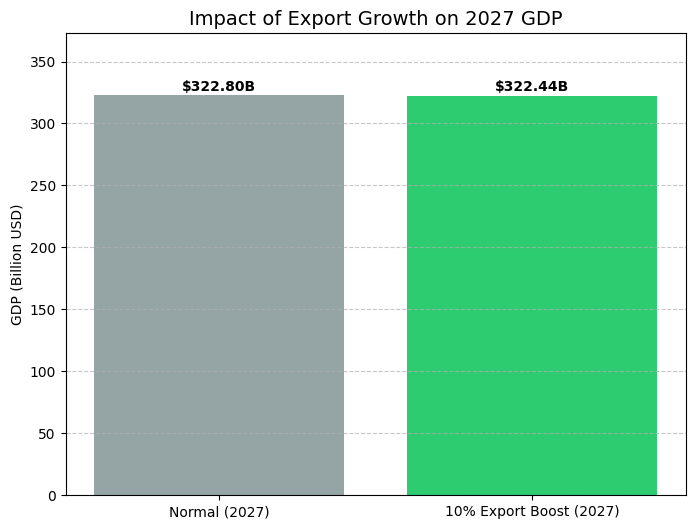

In [6]:
import matplotlib.pyplot as plt

# Jo scenarios humne calculate kiye hain
scenarios = ['Normal (2027)', '10% Export Boost (2027)']
gdp_values = [float(pred_normal[0]), float(pred_boosted[0])]

plt.figure(figsize=(8, 6))
bars = plt.bar(scenarios, gdp_values, color=['#95a5a6', '#2ecc71'])

# Bars ke upar values likhne ke liye
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'${yval:.2f}B', ha='center', va='bottom', fontweight='bold')

plt.title('Impact of Export Growth on 2027 GDP', fontsize=14)
plt.ylabel('GDP (Billion USD)')
plt.ylim(0, max(gdp_values) + 50) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

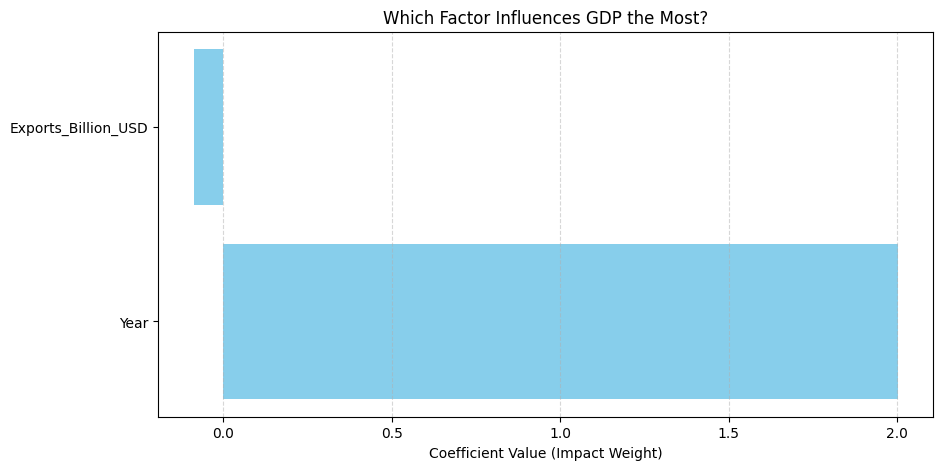

In [8]:
# Maan lijiye aapne X mein ['Year', 'Exports_Billion_USD'] rakha tha
features = ['Year', 'Exports_Billion_USD']
importance = model_multi.coef_

plt.figure(figsize=(10, 5))
plt.barh(features, importance, color='skyblue')
plt.xlabel('Coefficient Value (Impact Weight)')
plt.title('Which Factor Influences GDP the Most?')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

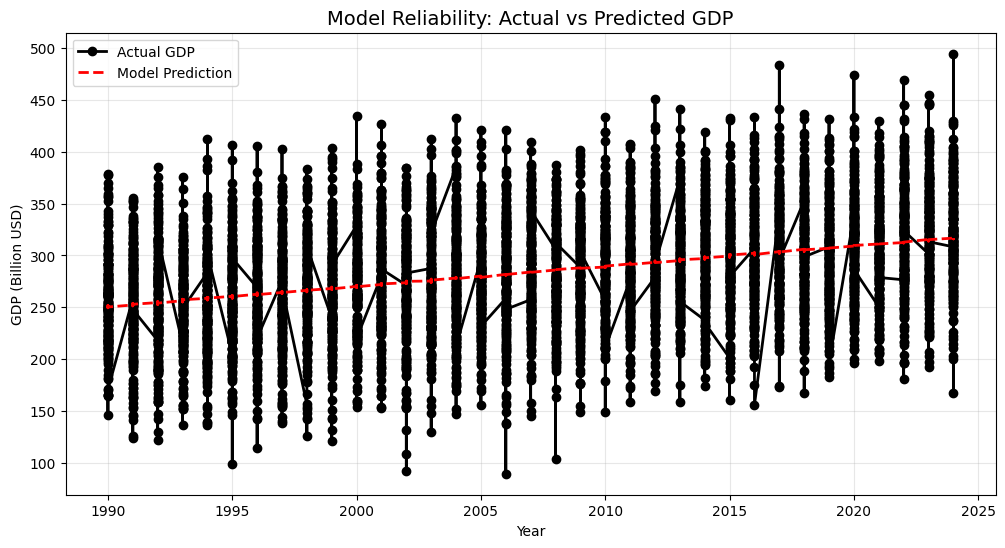

In [9]:
# Purane data par prediction lein
y_pred_all = model_multi.predict(df[['Year', 'Exports_Billion_USD']])

plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['GDP_Billion_USD'], label='Actual GDP', color='black', linewidth=2, marker='o')
plt.plot(df['Year'], y_pred_all, label='Model Prediction', color='red', linestyle='--', linewidth=2)

plt.title('Model Reliability: Actual vs Predicted GDP', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP (Billion USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
 # 1. GDP Per Capita Calculate karein (Billion USD to USD)
df['GDP_per_Capita'] = (df['GDP_Billion_USD'] * 1e9) / (df['Population_Million'] * 1e6)

# 2. Prediction Model (Year + Population se GDP per Capita predict karna)
from sklearn.linear_model import LinearRegression

X_pop = df[['Year', 'Population_Million']]
y_capita = df['GDP_per_Capita']

model_capita = LinearRegression()
model_capita.fit(X_pop, y_capita)

# 2027 ki population assume karte hain (agar trend 2% growth ka ho)
future_pop_2027 = df['Population_Million'].iloc[-1] * 1.05 # 5% increase in 3 years
pred_capita_2027 = model_capita.predict([[2027, future_pop_2027]])

print(f"Predicted GDP Per Capita in 2027: ${pred_capita_2027[0]:.2f}")

Predicted GDP Per Capita in 2027: $1689.13


C:\Users\PCP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


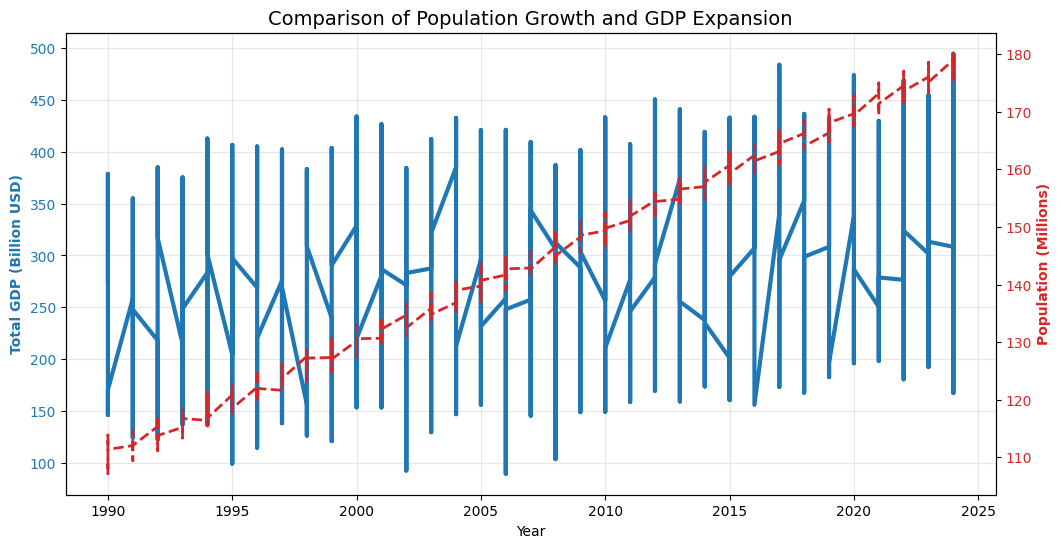

In [11]:
fig, ax1 = plt.subplots(figsize=(12,6))

# GDP Plot
ax1.set_xlabel('Year')
ax1.set_ylabel('Total GDP (Billion USD)', color='tab:blue', fontweight='bold')
ax1.plot(df['Year'], df['GDP_Billion_USD'], color='tab:blue', linewidth=3, label='GDP')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Population Plot (Secondary Axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Population (Millions)', color='tab:red', fontweight='bold')
ax2.plot(df['Year'], df['Population_Million'], color='tab:red', linestyle='--', linewidth=2, label='Population')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Comparison of Population Growth and GDP Expansion', fontsize=14)
ax1.grid(True, alpha=0.3)
plt.show()

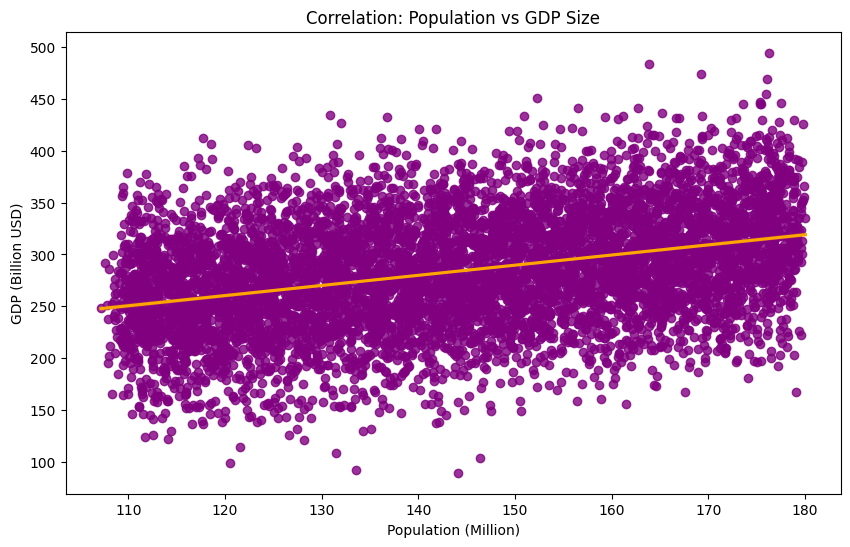

In [12]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(x='Population_Million', y='GDP_Billion_USD', data=df, scatter_kws={'color':'purple'}, line_kws={'color':'orange'})
plt.title('Correlation: Population vs GDP Size')
plt.xlabel('Population (Million)')
plt.ylabel('GDP (Billion USD)')
plt.show()